### Section 1. CLIP supplementary evaluation

This section performs a CLIP-based supplementary evaluation on the same image sets.

Unlike the blind LLM evaluation, this step does **not** rely on shuffled panels.  
Instead, CLIP directly measures image-text alignment by comparing each image with:
- **Van Gogh-related prompts**
- **generic painting prompts**

We use two complementary metrics:
- **Van Gogh similarity**: how strongly an image aligns with Van Gogh-style text prompts
- **style specificity**: how much Van Gogh alignment remains beyond generic painterly appearance

This step is used as supporting evidence rather than as the primary judgment of style recovery.

In [2]:
# Install OpenCLIP if needed
!pip install open-clip-torch -q

import torch
import open_clip
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

device = "cuda" if torch.cuda.is_available() else "cpu"

model_name = "ViT-B-32"
pretrained_name = "openai"

model, _, preprocess = open_clip.create_model_and_transforms(
    model_name,
    pretrained=pretrained_name
)
tokenizer = open_clip.get_tokenizer(model_name)

model = model.to(device)
model.eval()

print("Device:", device)
print("Model loaded:", model_name, pretrained_name)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.2 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


Device: cpu
Model loaded: ViT-B-32 openai


### Section 1.1 Define CLIP prompt sets

We define two prompt groups:

1. **Van Gogh prompts**  
   These prompts explicitly describe Van Gogh-like style traits.

2. **Generic painting prompts**  
   These prompts describe painterly images in a broader, non-specific way.

The difference between these two groups helps us estimate whether a model retains **Van Gogh-specific alignment**, rather than only general painterly appearance.






In [3]:
van_gogh_prompts = [
    "a painting in the style of Vincent van Gogh",
    "a Van Gogh style painting",
    "an expressive oil painting with bold brushstrokes in the style of van Gogh",
    "a post-impressionist painting with swirling brushstrokes and vivid colors",
    "a Van Gogh-like landscape painting"
]

generic_painting_prompts = [
    "a painting",
    "an oil painting",
    "a colorful painting",
    "an expressive painting",
    "a stylized landscape painting"
]

print("Van Gogh prompts:", len(van_gogh_prompts))
print("Generic prompts:", len(generic_painting_prompts))

Van Gogh prompts: 5
Generic prompts: 5


### Section 1.2 Encode text prompts

CLIP maps both images and text into the same feature space.  
Here we encode the two prompt groups and normalize their feature vectors before similarity calculation.

In [4]:
with torch.no_grad():
    vg_tokens = tokenizer(van_gogh_prompts).to(device)
    gp_tokens = tokenizer(generic_painting_prompts).to(device)

    vg_text_features = model.encode_text(vg_tokens)
    gp_text_features = model.encode_text(gp_tokens)

    vg_text_features = vg_text_features / vg_text_features.norm(dim=-1, keepdim=True)
    gp_text_features = gp_text_features / gp_text_features.norm(dim=-1, keepdim=True)

print("Text features ready.")

Text features ready.


### Section 1.3 Compute image-level CLIP scores

For each image, we compute:

- **van_gogh_similarity**: mean similarity to the Van Gogh prompt set
- **generic_similarity**: mean similarity to the generic painting prompt set
- **style_specificity**: `van_gogh_similarity - generic_similarity`

The last metric estimates how much Van Gogh-specific alignment remains beyond general painterliness.

In [5]:
from google.colab import drive
drive.mount('/content/drive')

import os
import pandas as pd
import torch
from PIL import Image

# 如果你还没装过 open_clip，就取消下一行注释运行一次
# !pip install open-clip-torch -q

import open_clip

# ===== 1. 定义路径 =====
OUT_DIR = "/content/drive/MyDrive/style_relearning_eval_blind_150"
MAPPING_PATH = f"{OUT_DIR}/blind_panel_mapping.csv"
CLIP_RESULTS_PATH = f"{OUT_DIR}/clip_supplementary_results_blind.csv"
CLIP_SUMMARY_PATH = f"{OUT_DIR}/clip_summary_blind.csv"

# ===== 2. 从 blind_panel_mapping.csv 重建 meta_df =====
mapping_df = pd.read_csv(MAPPING_PATH)

rows = []
for _, row in mapping_df.iterrows():
    rows.append({
        "image_idx": row["image_idx"],
        "model_type": row["left_model"],
        "image_path": row["left_path"]
    })
    rows.append({
        "image_idx": row["image_idx"],
        "model_type": row["middle_model"],
        "image_path": row["middle_path"]
    })
    rows.append({
        "image_idx": row["image_idx"],
        "model_type": row["right_model"],
        "image_path": row["right_path"]
    })

meta_df = pd.DataFrame(rows).drop_duplicates()
meta_df = meta_df.sort_values(["image_idx", "model_type"]).reset_index(drop=True)

print("meta_df rebuilt:")
print(meta_df.head())
print(meta_df["model_type"].value_counts())

# ===== 3. 加载 CLIP 模型 =====
device = "cuda" if torch.cuda.is_available() else "cpu"

model_name = "ViT-B-32"
pretrained_name = "openai"

model, _, preprocess = open_clip.create_model_and_transforms(
    model_name,
    pretrained=pretrained_name
)
tokenizer = open_clip.get_tokenizer(model_name)
model = model.to(device)
model.eval()

print("Device:", device)

# ===== 4. 定义 prompt sets =====
van_gogh_prompts = [
    "a painting in the style of Vincent van Gogh",
    "a Van Gogh style painting",
    "an expressive oil painting with bold brushstrokes in the style of van Gogh",
    "a post-impressionist painting with swirling brushstrokes and vivid colors",
    "a Van Gogh-like landscape painting"
]

generic_painting_prompts = [
    "a painting",
    "an oil painting",
    "a colorful painting",
    "an expressive painting",
    "a stylized landscape painting"
]

# ===== 5. 编码文本 =====
with torch.no_grad():
    vg_tokens = tokenizer(van_gogh_prompts).to(device)
    gp_tokens = tokenizer(generic_painting_prompts).to(device)

    vg_text_features = model.encode_text(vg_tokens)
    gp_text_features = model.encode_text(gp_tokens)

    vg_text_features = vg_text_features / vg_text_features.norm(dim=-1, keepdim=True)
    gp_text_features = gp_text_features / gp_text_features.norm(dim=-1, keepdim=True)

# ===== 6. 逐图计算 CLIP 分数 =====
clip_rows = []

for _, row in meta_df.iterrows():
    image = preprocess(Image.open(row["image_path"]).convert("RGB")).unsqueeze(0).to(device)

    with torch.no_grad():
        image_features = model.encode_image(image)
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)

        vg_sim = (image_features @ vg_text_features.T).mean().item()
        gp_sim = (image_features @ gp_text_features.T).mean().item()

    clip_rows.append({
        "image_idx": row["image_idx"],
        "model_type": row["model_type"],
        "image_path": row["image_path"],
        "van_gogh_similarity": vg_sim,
        "generic_similarity": gp_sim,
        "style_specificity": vg_sim - gp_sim
    })

clip_df = pd.DataFrame(clip_rows)
clip_df.to_csv(CLIP_RESULTS_PATH, index=False)

print("Saved:", CLIP_RESULTS_PATH)
print(clip_df.head())

# ===== 7. 汇总 =====
clip_means = clip_df.groupby("model_type")[[
    "van_gogh_similarity",
    "generic_similarity",
    "style_specificity"
]].mean()

print("\nCLIP means:")
print(clip_means)

clip_summary_df = pd.DataFrame({
    "metric": [
        "original_van_gogh_similarity",
        "unlearned_van_gogh_similarity",
        "relearned_150_van_gogh_similarity",
        "original_generic_similarity",
        "unlearned_generic_similarity",
        "relearned_150_generic_similarity",
        "original_style_specificity",
        "unlearned_style_specificity",
        "relearned_150_style_specificity",
    ],
    "value": [
        clip_means.loc["original", "van_gogh_similarity"],
        clip_means.loc["unlearned", "van_gogh_similarity"],
        clip_means.loc["relearned_150", "van_gogh_similarity"],
        clip_means.loc["original", "generic_similarity"],
        clip_means.loc["unlearned", "generic_similarity"],
        clip_means.loc["relearned_150", "generic_similarity"],
        clip_means.loc["original", "style_specificity"],
        clip_means.loc["unlearned", "style_specificity"],
        clip_means.loc["relearned_150", "style_specificity"],
    ]
})

clip_summary_df.to_csv(CLIP_SUMMARY_PATH, index=False)
print("Saved:", CLIP_SUMMARY_PATH)
print(clip_summary_df)

Mounted at /content/drive
meta_df rebuilt:
   image_idx     model_type                                         image_path
0          0       original  /content/drive/MyDrive/evaluation/original-150...
1          0  relearned_150  /content/drive/MyDrive/evaluation/relearned-15...
2          0      unlearned  /content/drive/MyDrive/evaluation/unlearned-15...
3          1       original  /content/drive/MyDrive/evaluation/original-150...
4          1  relearned_150  /content/drive/MyDrive/evaluation/relearned-15...
model_type
original         30
relearned_150    30
unlearned        30
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


Device: cpu
Saved: /content/drive/MyDrive/style_relearning_eval_blind_150/clip_supplementary_results_blind.csv
   image_idx     model_type  \
0          0       original   
1          0  relearned_150   
2          0      unlearned   
3          1       original   
4          1  relearned_150   

                                          image_path  van_gogh_similarity  \
0  /content/drive/MyDrive/evaluation/original-150...             0.311769   
1  /content/drive/MyDrive/evaluation/relearned-15...             0.289083   
2  /content/drive/MyDrive/evaluation/unlearned-15...             0.293577   
3  /content/drive/MyDrive/evaluation/original-150...             0.268954   
4  /content/drive/MyDrive/evaluation/relearned-15...             0.295346   

   generic_similarity  style_specificity  
0            0.269500           0.042269  
1            0.270497           0.018586  
2            0.270892           0.022685  
3            0.256795           0.012159  
4            0.264908   

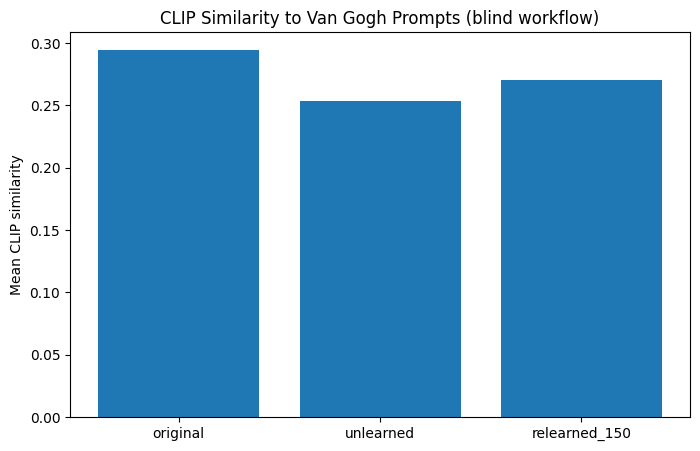

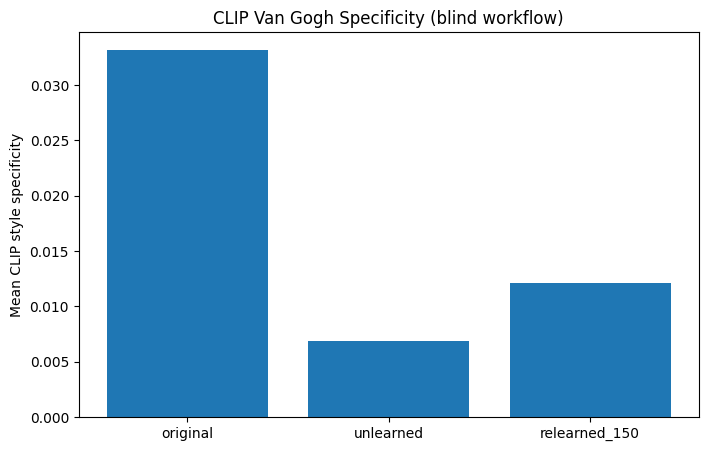

In [6]:
import matplotlib.pyplot as plt

model_order = ["original", "unlearned", "relearned_150"]

# Figure 1
plt.figure(figsize=(8,5))
plt.bar(model_order, [clip_means.loc[m, "van_gogh_similarity"] for m in model_order])
plt.ylabel("Mean CLIP similarity")
plt.title("CLIP Similarity to Van Gogh Prompts (blind workflow)")
plt.savefig(f"{OUT_DIR}/clip_similarity_van_gogh_blind.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

# Figure 2
plt.figure(figsize=(8,5))
plt.bar(model_order, [clip_means.loc[m, "style_specificity"] for m in model_order])
plt.ylabel("Mean CLIP style specificity")
plt.title("CLIP Van Gogh Specificity (blind workflow)")
plt.savefig(f"{OUT_DIR}/clip_specificity_van_gogh_blind.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

In [7]:
import pandas as pd

resolved_df = pd.read_csv(f"{OUT_DIR}/evaluated_resolved_results.csv")
clip_df = pd.read_csv(f"{OUT_DIR}/clip_supplementary_results_blind.csv")

avg_scores = resolved_df[[
    "original_style_score",
    "unlearned_style_score",
    "relearned_150_style_score"
]].mean()

status_counts = resolved_df["relearning_status"].value_counts()
most_counts = resolved_df["most_van_gogh_model"].value_counts()
least_counts = resolved_df["least_van_gogh_model"].value_counts()

clip_means = clip_df.groupby("model_type")[[
    "van_gogh_similarity",
    "generic_similarity",
    "style_specificity"
]].mean()

print("LLM average scores:")
print(avg_scores)

print("\nRelearning status:")
print(status_counts)

print("\nMost Van Gogh-like:")
print(most_counts)

print("\nLeast Van Gogh-like:")
print(least_counts)

print("\nCLIP means:")
print(clip_means)

LLM average scores:
original_style_score         5.00
unlearned_style_score        2.20
relearned_150_style_score    3.48
dtype: float64

Relearning status:
relearning_status
clearly relearned      23
partially relearned     2
Name: count, dtype: int64

Most Van Gogh-like:
most_van_gogh_model
original         24
relearned_150     1
Name: count, dtype: int64

Least Van Gogh-like:
least_van_gogh_model
unlearned        21
relearned_150     4
Name: count, dtype: int64

CLIP means:
               van_gogh_similarity  generic_similarity  style_specificity
model_type                                                               
original                  0.293987            0.260880           0.033107
relearned_150             0.270189            0.258039           0.012150
unlearned                 0.253581            0.246715           0.006866


In [8]:
final_summary = pd.DataFrame({
    "metric": [
        "original_mean_score",
        "unlearned_mean_score",
        "relearned_150_mean_score",
        "clearly_relearned_count",
        "partially_relearned_count",
        "not_relearned_count",
        "original_most_vangogh",
        "unlearned_most_vangogh",
        "relearned_150_most_vangogh",
        "original_least_vangogh",
        "unlearned_least_vangogh",
        "relearned_150_least_vangogh",
        "original_clip_vangogh_similarity",
        "unlearned_clip_vangogh_similarity",
        "relearned_150_clip_vangogh_similarity",
        "original_clip_style_specificity",
        "unlearned_clip_style_specificity",
        "relearned_150_clip_style_specificity",
    ],
    "value": [
        avg_scores["original_style_score"],
        avg_scores["unlearned_style_score"],
        avg_scores["relearned_150_style_score"],
        status_counts.get("clearly relearned", 0),
        status_counts.get("partially relearned", 0),
        status_counts.get("not relearned", 0),
        most_counts.get("original", 0),
        most_counts.get("unlearned", 0),
        most_counts.get("relearned_150", 0),
        least_counts.get("original", 0),
        least_counts.get("unlearned", 0),
        least_counts.get("relearned_150", 0),
        clip_means.loc["original", "van_gogh_similarity"],
        clip_means.loc["unlearned", "van_gogh_similarity"],
        clip_means.loc["relearned_150", "van_gogh_similarity"],
        clip_means.loc["original", "style_specificity"],
        clip_means.loc["unlearned", "style_specificity"],
        clip_means.loc["relearned_150", "style_specificity"],
    ]
})

FINAL_SUMMARY_PATH = f"{OUT_DIR}/final_blind_summary.csv"
final_summary.to_csv(FINAL_SUMMARY_PATH, index=False)

print("Saved:", FINAL_SUMMARY_PATH)
final_summary

Saved: /content/drive/MyDrive/style_relearning_eval_blind_150/final_blind_summary.csv


,metric,value
0,original_mean_score,5.000000
1,unlearned_mean_score,2.200000
2,relearned_150_mean_score,3.480000
3,clearly_relearned_count,23.000000
4,partially_relearned_count,2.000000
5,not_relearned_count,0.000000
6,original_most_vangogh,24.000000
7,unlearned_most_vangogh,0.000000
8,relearned_150_most_vangogh,1.000000
9,original_least_vangogh,0.000000


### Final summary

The blind LLM evaluation and the CLIP-based supplementary evaluation support the same overall ranking:

**original > relearned_150 > unlearned**

In the blind LLM evaluation, the original model received the highest style scores and was most frequently judged as the most Van Gogh-like. The unlearned model was most often judged as the least Van Gogh-like. The relearned_150 model recovered a substantial portion of Van Gogh-like style features, but it still remained below the original model.

The CLIP supplementary evaluation shows the same trend. The original model has the strongest alignment with Van Gogh-related prompts, the unlearned model has the weakest alignment, and the relearned_150 model falls between them on both Van Gogh similarity and style specificity.

Overall, these results suggest that style erasure is effective, while indirect fine-tuning on 150 images can restore part of the erased style signal, but the recovery remains incomplete.

In [10]:
import json
from google.colab import drive

drive.mount('/content/drive')

path = "/content/drive/MyDrive/clip_supplementary_results_150.ipynb"

with open(path, "r", encoding="utf-8") as f:
    nb = json.load(f)

if "metadata" in nb and "widgets" in nb["metadata"]:
    del nb["metadata"]["widgets"]

with open(path, "w", encoding="utf-8") as f:
    json.dump(nb, f, ensure_ascii=False, indent=1)

print("Cleaned notebook metadata.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Cleaned notebook metadata.
